In [1]:
pip install tensorflow numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1842s 11us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

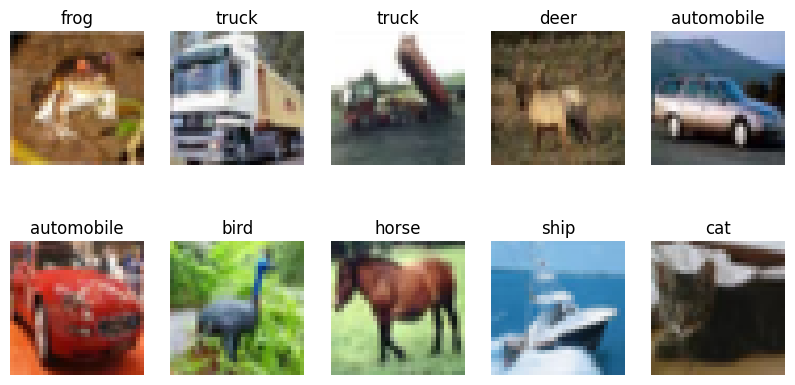

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [7]:
model = models.Sequential()

# Convolution Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Layer 3
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.4483 - loss: 1.5094 - val_accuracy: 0.5363 - val_loss: 1.2841
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5877 - loss: 1.1643 - val_accuracy: 0.6092 - val_loss: 1.1045
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6421 - loss: 1.0137 - val_accuracy: 0.6493 - val_loss: 0.9897
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6766 - loss: 0.9162 - val_accuracy: 0.6603 - val_loss: 0.9819
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7067 - loss: 0.8413 - val_accuracy: 0.6686 - val_loss: 0.9585
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7237 - loss: 0.7845 - val_accuracy: 0.6756 - val_loss: 0.9500
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.7406 - loss: 0.7366 - val_accuracy: 0.6989 - val_loss: 0.8769
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7560 -

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6958 - loss: 0.9460
Test Accuracy: 0.6958000063896179


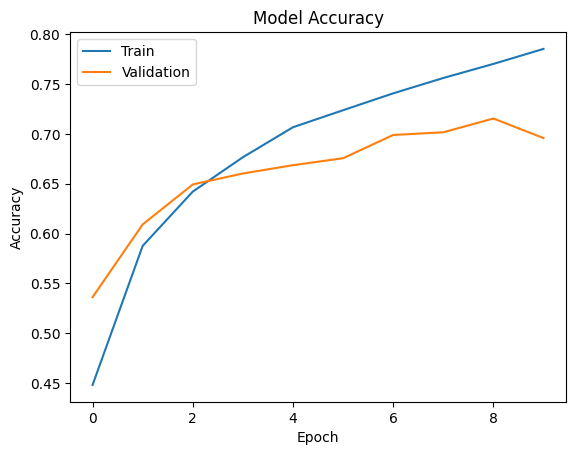

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

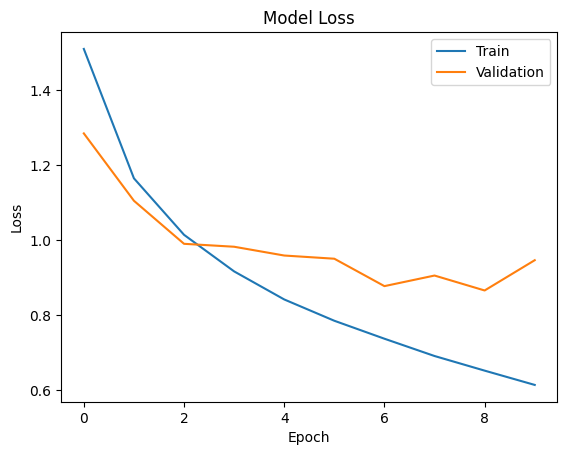

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [14]:
predictions = model.predict(X_test)

predicted_class = np.argmax(predictions[0])

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Predicted: cat
Actual: cat


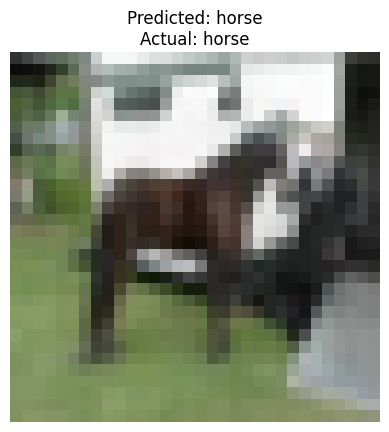

In [15]:
index = 20

plt.imshow(X_test[index])
plt.title(
    f"Predicted: {class_names[np.argmax(predictions[index])]}\n"
    f"Actual: {class_names[y_test[index][0]]}"
)
plt.axis('off')
plt.show()

In [16]:
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.72      0.76      0.74      1000
  automobile       0.83      0.81      0.82      1000
        bird       0.52      0.66      0.58      1000
         cat       0.47      0.60      0.53      1000
        deer       0.67      0.60      0.63      1000
         dog       0.62      0.59      0.60      1000
        frog       0.80      0.76      0.78      1000
       horse       0.88      0.61      0.72      1000
        ship       0.76      0.87      0.81      1000
       truck       0.86      0.71      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



In [17]:
model.save("cifar10_image_classifier.h5")

In [23]:
from tensorflow.keras.datasets import cifar10
import numpy as np

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

sample = X_test[0]

prediction = model.predict(
    np.expand_dims(sample/255.0, axis=0)
)

classes = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("Actual:", classes[y_test[0][0]])
print("Predicted:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
Actual: cat
Predicted: cat
